# Background

###### COMP4670/8600 - Statistical Machine Learning

This tutorial will introduce the *basic elements* for writing Python programs, and using 
[Jupyter notebooks](http://jupyter.org/). 

Due to the wide variety of backgrounds that students may have, it is worth recalling some mathematics and statistics that we build upon in this course.

### Overview of this Notebook:

#### 1. Basic Statistical Knowledge
   - 1.1 Random Variables
   - 1.2 Discrete Probabilities
   - 1.3 Differentiation
   - 1.4 Integration
   - 1.5 Change-of-variable

#### 2. Python and Programming for Machine Learning [Optional]
*If you already know Python and Jupyter notebooks well, please skip this section and start working on Tutorial 1b "Matrix decomposition".*
   - 2.1 Installation
   - 2.2 Jupyter Notebooks
   - 2.3 Toy Dataset for Debugging
   - 2.4 Reading and Writing CSV

$\newcommand{\RR}{\mathbb{R}}$
## 1. Basic statistical knowledge

Let's refresh our memory about some concepts.

### 1.1 Random variables

Write down the definitions of the following entities, and provide a simple example to illustrate.
1. The expectation of a function $f$ with respect to a
   * continuous random variable $X$
   * discrete random variable $X$
2. The variance of a random variable $X$.
3. Independence of two random variables $X$ and $Y$

### <span style="color:blue">Solution</span>

1. Expectation
    * Continuous random variable:
        * $\mathbb{E}[f]=\int p(x)f(x)dx$
        * Example: $x \in [0,1]$, $p(x)=1$ (ie. constant), $f(x)=x^2$. $\mathbb{E}[f]=\int_0^1x^2dx=[\frac{1}{3}x^3]^1_0=\frac{1}{3}$.
    * Discrete random variable:
        * $\mathbb{E}[f]=\sum\limits_{x}p(x)f(x)$  
        * Example: $x \in \{0,1\}$, $p(1)=\frac{1}{1000},p(0)=\frac{999}{1000}$, $f(1)=100,f(0)=0$. $\mathbb{E}[f]=\frac{1}{1000}\times 100 + \frac{999}{1000} \times 0=0.1$.  
2. Variance: $\text{Var}(X)=\mathbb{E}[(X-\mathbb{E}[X])^2]$
    * Example (continuing discrete random variable example above): $Var(X)=\frac{1}{1000}\times(100-0.1)^2 + \frac{999}{1000} \times (0-0.1)^2=9.99$.
3. Independence: $p(x,y)=p(x)p(y)$. Example shown in table below:
    
| | X=heads | X=tails | Total|
|:--:|:--------------------------:|:--:|:--:|
| Y = cloudy |0.15 |0.15 |0.3|
| Y = sunny |0.35|0.35|0.7|
|Total|0.5|0.5|1|

### 1.2 Discrete probabilities

For discrete random variables $X$ and $Y$, define the following, and show an example of how it applies to the example below.

| $p(\mathbf{X},\mathbf{Y})$ | X=a | X=b | X=c | X=d | X=e |
|:--------------------------:|:--:|:--:|:--:|:--:|:--:|
| **Y** = red |0.2 |0.1 |0.1 |0.01|0.04|
| **Y** = green |0.08|0.07|0.01|0.05|0.05|
| **Y** = blue |0.01|0.01|0.07|0.05|0.15|

1. The sum rule of probability theory
2. The product rule of probability theory
3. Independence of two random variables $X$ and $Y$

### <span style="color:blue">Solution</span>
1. Sum rule
    * $p(Y=y)=\sum\limits_xp(X=x,Y=y)$
    * Example: $p(Y=red)=\sum\limits_xp(X=x,Y=red)=0.2+0.1+0.1+0.01+0.04=0.45$.
2. Product rule
    * $p(X=x,Y=y)=p(X=x)p(Y=y|X=x)$
    * Example: $p(X=a,Y=red)=p(X=a)p(Y=red|X=a)=(0.2+0.08+0.01)\times\frac{0.2}{0.2+0.08+0.01}=0.2$.
3. Independence:
    * see definition in previous question
    * Example: 
        * $p(X=a,Y=red)=0.2$
        * $p(X=a)p(Y=red)=(0.2+0.08+0.01)\times(0.2+0.1+0.1+0.01+0.04)=0.29\times0.45=0.1305$.
        * Therefore $X$ and $Y$ are not independent.

### 1.3 Differentiation

Compute the gradient of the following function $f:\RR\to\RR$
$$
f(x) = \frac{1}{1 + \exp(x^2)}
$$
What would the the gradient if $x$ was two dimensional (that is $f:\RR^2\to\RR$)? Generalise the scalar function above appropriately.

### <span style="color:blue">Solution</span>
* One dimension
$$\frac{df}{dx}=\frac{-2x\exp(x^2)}{(1+\exp(x^2))^2}$$
* Two dimensions

$x^2$ is not defined if $x$ is a vector. However, if $$f(x) = \frac{1}{1 + \exp(||x||^2)}=\frac{1}{1 + \exp(x_1^2+x_2^2)}$$

then

$$\nabla{f}=\begin{bmatrix}\frac{\partial f}{\partial x_1}\\\frac{\partial f}{\partial x_2}\end{bmatrix}=\frac{-2\exp(||x||^2)}{(1+\exp(||x||^2))^2}\begin{bmatrix}x_1\\x_2\end{bmatrix}$$

### 1.4 Integration
Write down the answer to the integrals below. Given $F'=f.$
1. Definite integral $\int_a^bf(x)dx$
2. Indefinite integral $\int f(x)dx$

### <span style="color:blue">Solution</span>
1. Definite integral $\int_a^bf(x)dx= F(b)- F(a)$
2. Indefinite integral $\int f(x)dx = F(x)+C$ where $C$ is a constant

### 1.5 Change-of-variable

In statistics, understanding the transformation of random variables, or change of random variables, is crucial when working with probability distributions. 

Let's consider a scenario where we have a random variable X with probability density function p(X), and we want to find the probability density function of a new variable Y and we define X = g(Y).

To obtain the probability density function p(Y) for the transformed variable Y, we can use the probability density function transformation formula. For a one-to-one transformation, the formula is given by:

$$ p_Y(y) = p_X(x) \left| \frac{dx}{dy} \right|  = p_X(g(y))\left| g' (y)\right|$$


For example, define x = g(y) = $y^{-3}$, then given p(X), we could obtain

$$p_Y(y) = p_X(g(y))\left| g' (y)\right| = p(X)\left|(y^{-3})'\right| = 3 p(X) \left|y^{-4}\right|$$


This transformation allows us to derive the probability density function p_Y(y) for the variable Y in terms of the original probability density function p_X(x). Understanding such transformations is fundamental when dealing with complex statistical analyses and modeling.

**Extension: if interested, consider how to extend this change-of-variable technique to a higher-dimensional space, that is when the random variables X and Y here are defined as vectors instead of 1D values, what will be the change-of-variable rule?**

### <span style="color:blue">Solution</span>
$$ p_Y(\mathbf{y}) = p_X(\mathbf{x}) \left| \text{det} \left(\frac{d g(\mathbf{y})}{d\mathbf{y}} \right) \right| $$ where the term $\frac{d g(\mathbf{y})}{d\mathbf{y}}$ is also called the Jacobian of the mapping $g$.

## 2. Python and Programming for Machine Learning

*If you already know Python and Jupyter notebooks well, please skip this section and start working on Tutorial 1b "Matrix decomposition"*

The introduction will focus on the concepts necessary for writing small programs in Python for the purpose of Machine Learning. That means, we expect a user of the code will be a reasonable knowledgeable person. Therefore, we can *skip* most of the code a robust system would have to contain in order to *check* the input types, *verify* the input parameter ranges, and *make sure* that really nothing can go wrong when somebody else is using the code.
Having said this, you are nevertheless encouraged to include some sanity tests into your code to avoid making simple errors which can cost you a lot of time to find.
Some of the Python concepts discussed in the tutorial will be
- Data types (bool, int, float, str, list, tuple, set, dict)
- Operators
- Data flow
- Functions
- Classes and objects
- Modules and how to use them

**We will be using [Python3](https://wiki.python.org/moin/Python2orPython3) in this course**.

Some resources:
- [CodeAcademy](http://www.codecademy.com/en/tracks/python) gives a step by step introduction to python
- [How to think like a computer scientist](https://openbookproject.net/thinkcs/python/english3e/) does what it says, using Python

### 2.1 Installation

The easiest way to get a working Python environment is using one of the following collections:
- [Enthought canopy](https://store.enthought.com/)
- [Anaconda](https://www.anaconda.com/download)

It is also not too difficult to install python using your favourite package manager and then use [conda](http://conda.pydata.org/docs/) or [pip](https://pip.pypa.io/en/stable/installation/) to manage python packages.

### 2.2 Jupyter Notebooks

**To work on a worksheet or assignment, download the notebook and edit it locally.**

[Jupyter notebooks](http://jupyter.org/) provide a convenient browser based environment for data analysis in a literate programming environment. The descriptive parts of the notebook implements an enhanced version of [markdown](http://daringfireball.net/projects/markdown/syntax), which allows the use of [LaTeX](http://www.latex-project.org/) for rendering equations.
1. Descriptive notes
   - Markdown
   - LaTeX
2. Computational code
   - numerical python
      * numpy
      * scipy
   - matplotlib
   
To use a notebook locally, run the following in your terminal:
```bash
jupyter notebook name_of_file.ipynb
```

### 2.2.1 Markdown and LaTeX

In addition to lists and links which are already shown above, 
tables are also nice and easy

|Title | Middle| Left aligned | Right aligned |
|------|:-----:|:-----|--:|
|Monday|10:00|Sunny|*30*|
|Thursday|12:32|Rain|*22.3*|

It is also easy to typeset good looking equations inline, such as $f(x) = x^2$, or on a line by itself.
\begin{equation}
    g(x) = \sum_{i=1}^n \frac{\prod_{j=1}^d y_j \sqrt{3x_i^4}}{f(x_i)}
\end{equation}
If you use a symbol often, you can define it at the top of a document as follows (look at source), and use it in equations.

$\newcommand{\amazing}{\sqrt{3x_i^4}}$

\begin{equation}
    h(x) = \sum_{i=1}^n \amazing
\end{equation}

###  2.2.2 Computational code

Setting up python environment ([do not use pylab](https://carreau.github.io/posts/10-No-PyLab-Thanks))

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

%matplotlib inline

Some resources:
* [Tentative NumPy Tutorial](http://wiki.scipy.org/Tentative_NumPy_Tutorial)
* [SciPy Tutorial](https://docs.scipy.org/doc/scipy/tutorial/)
* [Matplotlib PyPlot Tutorial](http://matplotlib.org/1.3.1/users/pyplot_tutorial.html)


### 2.3 Toy dataset for debugging

Write a function ```gen_data``` that generates data from two Gaussians with unit variance, centered at $\mathbf{1}$ and $-\mathbf{1}$ respectively. $\mathbf{1}$ is the vector of all ones.

*Hint: use ```np.ones``` and ```np.random.randn```*

Use the function to generate 100 samples from each Gaussian, with a 5 dimensional feature space.

In [3]:
# Solution
def gen_data(n_samples=100, n_feat=5):
    """Generate data from two Gaussians
    n_samples = number of samples from each Gaussian
    n_feat = dimension of the features
    """
    X1 = np.ones((n_feat, n_samples))   + np.random.randn(n_feat, n_samples)
    X2 = - np.ones((n_feat, n_samples)) + np.random.randn(n_feat, n_samples)
    X  = np.hstack([X1,X2])
    return X

toy_data = gen_data()

Use ```gen_data``` to generate 100 samples from each Gaussian, with a 2 dimensional feature space. Plot this data.

Discuss:
- Can you see two bumps?
- Does the data look Gaussian?
- What happens with more dimensions?

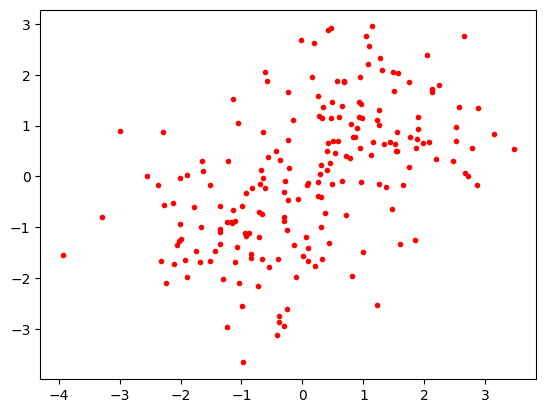

In [6]:
# Solution
X = gen_data(100, 2)
plt.plot(X[0,:], X[1,:], 'r.')
plt.show()

### 2.4 Reading the writing CSV
Write a file containing the data to a csv file. Confirm that you can read this data using python and also manually inspect the file with a text editor.

In [7]:
# Solution
np.savetxt('two-gaussians.csv', X.T, delimiter=',')
X_loaded_transpose = np.loadtxt('two-gaussians.csv', delimiter=',')
X_loaded = X_loaded_transpose.T
assert np.allclose(X_loaded, X)